In [1]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# טעינת הנתונים - קובץ JSONL
df = pd.read_json('/content/drive/MyDrive/nlp_pro2/data_sets/cleaned/train.full.clean.jsonl', lines=True)


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# 1. יצירת מפתח משולב לאיזון (Stratification)
# שילוב של Genre ו-Label מבטיח שכל תת-קבוצה תיוצג בכל החלקים
df['stratify_key'] = df['label'].astype(str) + "_" + df['genre'].astype(str)

# 2. סינון קבוצות קטנות מדי
# כדי לחלק דגימות ל-3 קבוצות (70/15/15), אנחנו חייבים לפחות 3 דגימות מכל סוג
counts = df['stratify_key'].value_counts()
small_groups = counts[counts < 3].index

if not small_groups.empty:
    print(f"מסיר {len(small_groups)} קבוצות קטנות מדי שלא ניתן לחלק ל-3 חלקים.")
    df = df[~df['stratify_key'].isin(small_groups)]

# 3. חלוקה ראשונה: 70% לאימון (Train) ו-30% הנותרים (Temp)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df['stratify_key'] # הבטחת האיזון בשלב האימון
)

# 4. חלוקה שנייה: חלוקת ה-30% הנותרים שווה בשווה (15% ו-15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['stratify_key'] # הבטחת האיזון בולדיציה ובטסט
)

# 5. ניקוי עמודת העזר והצגת תוצאות
for d in [train_df, val_df, test_df]:
    d.drop(columns=['stratify_key'], inplace=True)

print(f"חלוקה הסתיימה:")
print(f"- Train (70%): {len(train_df)} שורות")
print(f"- Validation (15%): {len(val_df)} שורות")
print(f"- Test (15%): {len(test_df)} שורות")

# 6. שמירה ל-Google Drive בפורמט JSONL
project_path = '/content/drive/MyDrive/nlp_pro2/data_sets/Separated'
if not os.path.exists(project_path):
    os.makedirs(project_path)

train_df.to_json(f'{project_path}/train.jsonl', orient='records', lines=True, force_ascii=False)
val_df.to_json(f'{project_path}/val.jsonl', orient='records', lines=True, force_ascii=False)
test_df.to_json(f'{project_path}/test.jsonl', orient='records', lines=True, force_ascii=False)

print(f"\nהקבצים נשמרו בנתיב: {project_path}")

חלוקה הסתיימה:
- Train (70%): 209809 שורות
- Validation (15%): 44959 שורות
- Test (15%): 44960 שורות

הקבצים נשמרו בנתיב: /content/drive/MyDrive/nlp_pro2/data_sets/Separated


In [12]:
!pip install pandas python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 6.2 MB/s eta 0:00:00


In [13]:
import pandas as pd
from bidi.algorithm import get_display

# פונקציה לחישוב אחוזים
def get_label_distribution(df, name):
    dist = df['label'].value_counts(normalize=True) * 100
    return dist.rename(name)

# שילוב התוצאות לטבלה אחת
comparison_df = pd.concat([
    get_label_distribution(train_df, 'Train (%)'),
    get_label_distribution(val_df, 'Validation (%)'),
    get_label_distribution(test_df, 'Test (%)')
], axis=1)

print("--- התפלגות Labels בכל קבוצה (באחוזים) ---")
print(comparison_df.round(2))

--- התפלגות Labels בכל קבוצה (באחוזים) ---
               Train (%)  Validation (%)  Test (%)
label                                             
entailment         33.65           33.65     33.65
contradiction      33.20           33.20     33.20
neutral            33.15           33.15     33.15


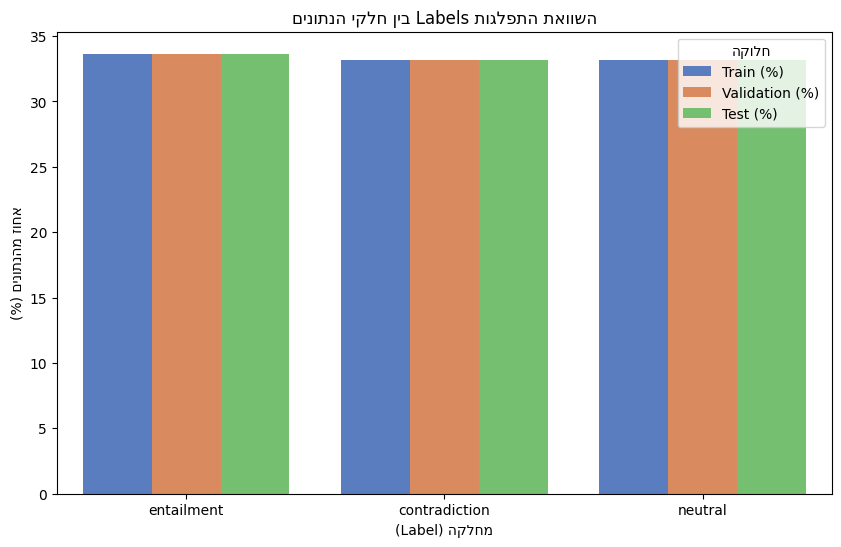

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# הכנת הנתונים לגרף
plot_data = comparison_df.reset_index().melt(id_vars='label', var_name='Split', value_name='Percentage')

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='label', y='Percentage', hue='Split', palette='muted')

plt.title(get_display("השוואת התפלגות Labels בין חלקי הנתונים"))
plt.xlabel(get_display("מחלקה (Label)"))
plt.ylabel(get_display("אחוז מהנתונים (%)"))
plt.legend(title=get_display("חלוקה"))
plt.show()

We see the train val and test have the same % of each lebel

In [16]:
import pandas as pd
from bidi.algorithm import get_display

# פונקציה לחישוב אחוזים עבור ז'אנר
def get_genre_distribution(df, name):
    # חישוב אחוזים לכל ז'אנר בשבר עשרוני והכפלה ב-100
    dist = df['genre'].value_counts(normalize=True) * 100
    return dist.rename(name)

# איחוד הנתונים לטבלה אחת להשוואה
genre_comparison_df = pd.concat([
    get_genre_distribution(train_df, 'Train (%)'),
    get_genre_distribution(val_df, 'Validation (%)'),
    get_genre_distribution(test_df, 'Test (%)')
], axis=1).fillna(0) # מילוי ב-0 אם ז'אנר חסר באחת הקבוצות

print("--- התפלגות ז'אנרים בכל קבוצה (באחוזים) ---")
print(genre_comparison_df.round(2))

--- התפלגות ז'אנרים בכל קבוצה (באחוזים) ---
            Train (%)  Validation (%)  Test (%)
genre                                          
government      25.38           25.38     25.39
travel          25.02           25.02     25.02
fiction         24.27           24.27     24.27
slate           23.42           23.43     23.42
letters          0.64            0.65      0.64
oup              0.64            0.64      0.64
nineeleven       0.61            0.61      0.61


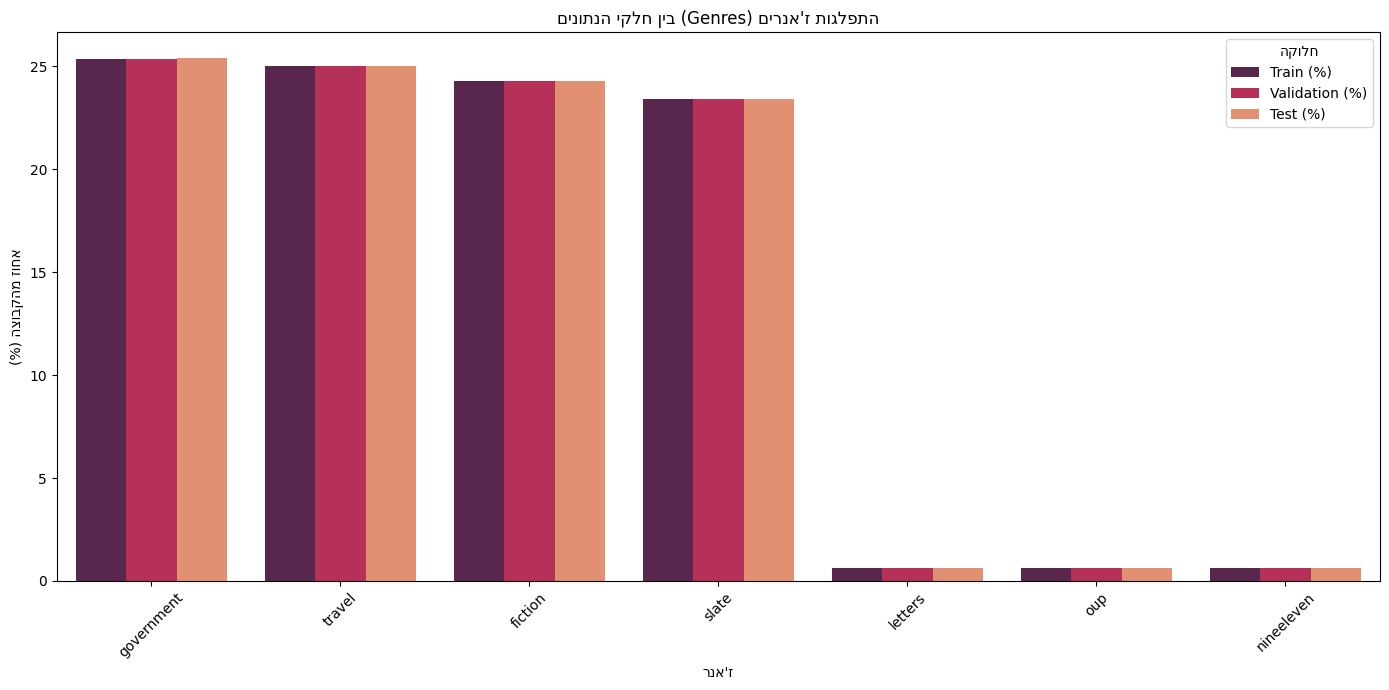

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# הכנת הנתונים למבנה מתאים לגרף
genre_plot_data = genre_comparison_df.reset_index().melt(id_vars='genre', var_name='Split', value_name='Percentage')

plt.figure(figsize=(14, 7))
sns.barplot(data=genre_plot_data, x='genre', y='Percentage', hue='Split', palette='rocket')

plt.title(get_display("התפלגות ז'אנרים (Genres) בין חלקי הנתונים"))
plt.xlabel(get_display("ז'אנר"))
plt.ylabel(get_display("אחוז מהקבוצה (%)"))
plt.xticks(rotation=45)
plt.legend(title=get_display("חלוקה"))
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

def show_detailed_counts(df, name):
    print(f"\n--- כמויות מפורטות עבור: {name} ---")
    # יצירת טבלת הצלבה בין Genre ל-Label
    counts_table = pd.crosstab(df['genre'], df['label'], margins=True, margins_name="סך הכל")
    display(counts_table)

# הרצה על שלושת החלקים
show_detailed_counts(train_df, "Train (אימון)")
show_detailed_counts(val_df, "Validation (ולדיציה)")
show_detailed_counts(test_df, "Test (בחינה)")


--- כמויות מפורטות עבור: Train (אימון) ---


label,contradiction,entailment,neutral,סך הכל
genre,,,,
fiction,16970,17094,16865,50929
government,17717,17805,17736,53258
letters,434,514,403,1351
nineeleven,431,454,394,1279
oup,434,473,442,1349
slate,16299,16611,16233,49143
travel,17372,17643,17485,52500
סך הכל,69657,70594,69558,209809



--- כמויות מפורטות עבור: Validation (ולדיציה) ---


label,contradiction,entailment,neutral,סך הכל
genre,,,,
fiction,3636,3663,3614,10913
government,3796,3815,3800,11411
letters,93,110,87,290
nineeleven,93,98,85,276
oup,93,101,95,289
slate,3493,3560,3479,10532
travel,3722,3780,3746,11248
סך הכל,14926,15127,14906,44959



--- כמויות מפורטות עבור: Test (בחינה) ---


label,contradiction,entailment,neutral,סך הכל
genre,,,,
fiction,3637,3663,3614,10914
government,3797,3816,3801,11414
letters,93,110,86,289
nineeleven,92,97,84,273
oup,93,101,95,289
slate,3493,3559,3478,10530
travel,3723,3781,3747,11251
סך הכל,14928,15127,14905,44960


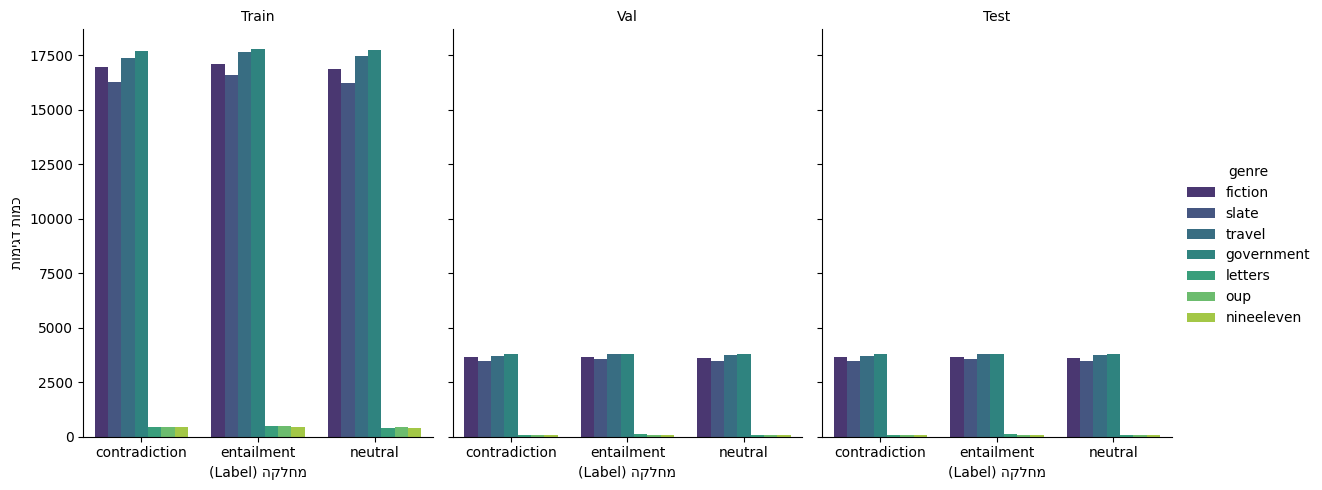

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from bidi.algorithm import get_display

# הכנת דאטה מאוחד לצורך הגרף
train_df['split'] = 'Train'
val_df['split'] = 'Val'
test_df['split'] = 'Test'
combined_df = pd.concat([train_df, val_df, test_df])

# יצירת גרף השוואתי
g = sns.catplot(
    data=combined_df,
    x='label',
    hue='genre',
    col='split',
    kind='count',
    palette='viridis',
    height=5,
    aspect=0.8
)

# התאמת כותרות לעברית
g.set_axis_labels(get_display("מחלקה (Label)"), get_display("כמות דגימות"))
g.set_titles("{col_name}")
plt.show()